# Train een worm om te kruipen

In deze notebook ga je aan de slag met versterkend leren. Je traint zelf een worm om te leren kruipen. 

De notebook bestaat uit de volgende stappen:
1. Je onderzoekt hoe een worm kruipt.
2. Je stelt de worm abstract voor door een reeks van segmenten.
3. Je legt vast wat de agent, de omgeving, de toestand, de beloning, en de acties zijn.
4. Je gaat op zoek naar een optimaal beleid door een waardefunctie te leren op basis van de beloningen.



## Hoe kruipt een worm?

Je bent zeker al eens een worm tegengekomen wanneer je aan het graven was in de tuin. Heb je dan al eens stilgestaan bij hoe zo'n worm zich verplaatst onder de grond? Dat is niet zo evident, wormen hebben immers geen poten. Beeld je in dat we je omwikkelen met duct tape en we je begraven in de grond, kan je je dan nog verplaatsen?

### De morfologie van een worm

De **bouw en de vorm** van een organisme noemen we de **morfologie** van dat organisme. Deze morfologie zorgt ervoor dat de worm zich onder de grond kan verplaatsen. 

**Segmenten**

Een worm is opgebouwd uit afgescheiden segmenten die gevuld zijn met vocht.

![Segmenten van de worm](img/worm_base.png)

**Spieren**

Over de lengte van de worm lopen lengtespieren.

![Lengtespieren van de worm](img/worm_long_muscles.png)

Naast de lentespieren heeft de worm ook kringspieren die rondom het lichaam van de worm lopen.

![Kringspieren van de worm](img/worm_long_and_short_muscles.png)


**Haartjes**

Op het lichaam van de worm zitten ook kleine haartjes. Deze zorgen ervoor dat de worm meer grip heeft op de aarde er rondom.

### De bewegingen van de worm

De worm kan elk segment op twee mogelijke manieren bewegen.

**Samentrekken lengtespieren**

Door de lengtespieren in een segment samen te trekken wordt de lengte van het segment korter. Omdat het segment gevuld is met vocht en vocht niet samendrukbaar is, zorgt dat ervoor dat de buitenkant van de worm uitzet door de druk.

![Inkorten van een segment.](img/worm_contracted.png)

Omgekeerd door de kringspieren in een segment samen te trekken wordt de omtrek van het segment korter. Daardoor zal het segment door de druk langer worden.

![Uitzetten van een segment](img/worm_expanded_segment.png)

Een ingekort segment zorgt voor meer druk op de aarde rondom de worm. De haartjes op de worm grijpen op die plaats dus de aarde vast. Een uitgezet segment zorgt ervoor dat de worm langer en dunner wordt daardoor is er minder wrijving op de aarde rondom de worm en kan dat stuk zich makkelijker vooruit en achteruit bewegen.

Door de lengte- en kringspieren in een correct patroon samen te trekken en los te laten, kan de worm zich vooruit bewegen. Het is dit patroon dat we een virtuele worm zullen proberen te leren via versterkend leren.

# De virtuele worm

Voor we de virtuele worm aanmaken importeren we eerst de nodige bibliotheken. Zoals altijd hebben we al wat code geschreven om van te vertrekken. Zo kunnen we in deze notebook focussen op wat belangrijk is om de worm te trainen. Wil je graag die code bekijken dan kan dat in het bestand *scripts/helpers.py*.

In [1]:
from scripts.helpers import Worm

Om het probleem wat te vereenvoudigen, stellen we onze worm voor als een lijst van segmenten. Elk segment kan ofwel lang zijn ofwel kort zijn. We laten de neutrale toestand van de spieren weg, zo zal het makkelijker zijn om een bewegingspatroon te leren. 

Voor de virtuele worm hebben we een klasse gemaakt. Deze bevat de lijst van segmenten en functies om een segment lang of kort te maken. Onderstaande code maakt een worm met 5 segmenten.

In [2]:
worm = Worm(5)

Wanneer we de worm afdrukken krijgen we een lijst van letters. Elke letter stelt de toestand van een segment voor, K voor kort en L voor lang. We hebben ervoor gekozen om alle segmenten kort te maken bij het creëren van een worm.

In [3]:
print(f"De starttoestand van de worm is: {worm}")

De starttoestand van de worm is: KKKKK


Het worm object heeft een aantal functies (methodes) die we kunnen gebruiken om de toestand van de worm te veranderen. De volgende code drukt die methodes af.

In [4]:
# Druk de af welke methodes de worm heeft
print("De worm heeft de volgende methodes:")
methodes = [method_naam for method_naam in dir(worm) if callable(getattr(worm, method_naam))]
for method in methodes:
    if not method.startswith("__"):
        print(f"- {method}")

De worm heeft de volgende methodes:
- maak_segment_korter
- maak_segment_langer
- positie_van_het_hoofd
- posities_van_de_segmenten
- segmenten
- teken_worm
- zit_segment_tussen_twee_korte_segmenten


Je merkt dat er een methode is om de worm te tekenen. Laten we die eens uitproberen.

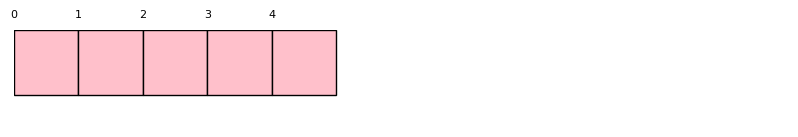

In [5]:
worm.teken_worm()

Je ziet dat alle elementen van de worm momenteel kort zijn. Met de methode *maak_segment_langer* kan je een van de segmenten lang maken. Aan de methode geef je het nummer van het segment mee. De segmenten worden genummerd vanaf 0.

De worm is nu: KKKKL


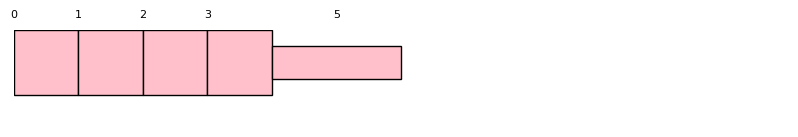

In [6]:
worm.maak_segment_langer(4)
print(f"De worm is nu: {worm}")
worm.teken_worm()

**Opmerking**

De korte segmenten zijn dik en drukken tegen de aarde rondom de worm. De haartjes van de worm grijpen de aarde zo vast. Bijgevolg is het niet mogelijk om een segment dat tussen twee korte segmenten zit, lang te maken. De worm zou in dat geval naar links of rechts moeten bewegen. Maar omdat aan beide zijden van het segment korte segmenten zijn, lukt dat niet. Je ziet bijvoorbeeld dat het langer maken van segment 2 geen effect heeft.

De worm is nu: KKKKL


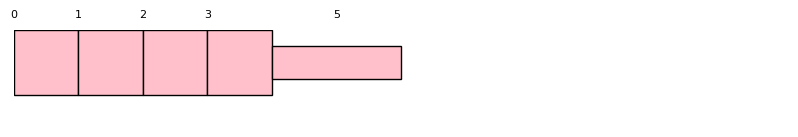

In [7]:
worm.maak_segment_langer(4)
print(f"De worm is nu: {worm}")
worm.teken_worm()

Door segmenten in het juiste patroon korter of langer te maken, kan de worm zich voortbewegen.

**Opdracht**: pas een sequentie van bewegingen toe op de worm en zorg er zo voor dat de staart van de worm twee posities naar rechts opschuift. Druk na elke verschuiving de worm af op het scherm.

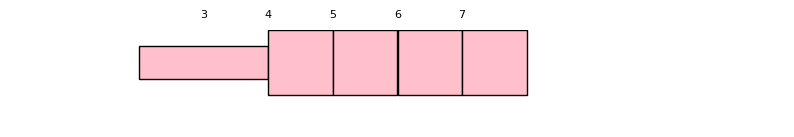

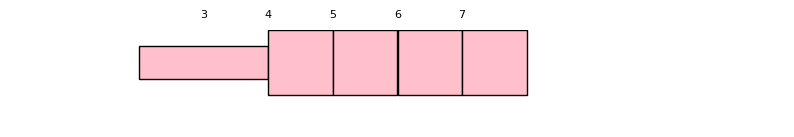

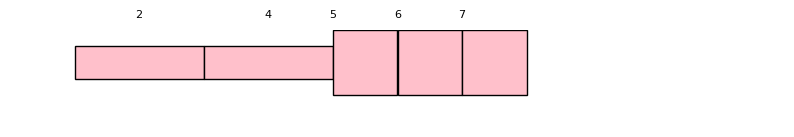

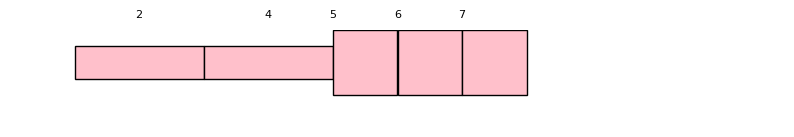

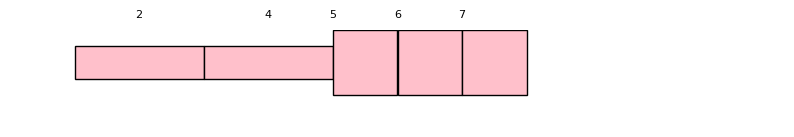

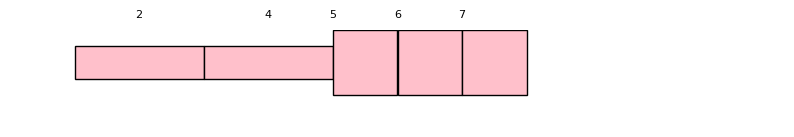

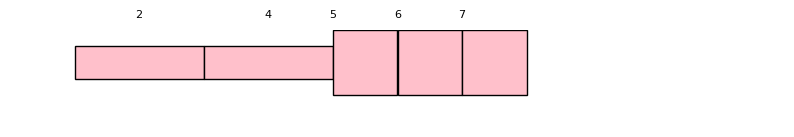

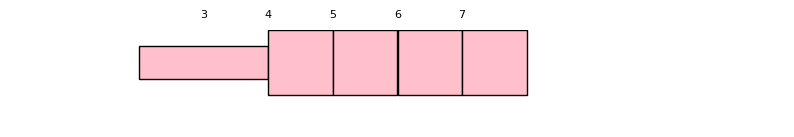

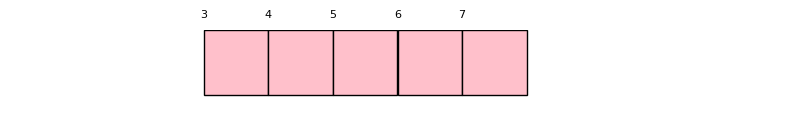

In [9]:
# Schrijf hier de code om de worm te doen bewegen.
worm.maak_segment_langer(3)
worm.teken_worm()
worm.maak_segment_langer(2)
worm.teken_worm()
worm.maak_segment_langer(1)
worm.teken_worm()
worm.maak_segment_korter(4)
worm.teken_worm()
worm.maak_segment_langer(0)
worm.teken_worm()
worm.maak_segment_korter(3)
worm.teken_worm()
worm.maak_segment_korter(2)
worm.teken_worm()
worm.maak_segment_korter(1)
worm.teken_worm()
worm.maak_segment_korter(0)
worm.teken_worm()